In [21]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [22]:
import matplotlib
matplotlib.use("inline")

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

In [23]:
import tensorflow as tf

In [24]:
spatial_geom = dde.geometry.Rectangle([0.0, 0.0], [1.0, 0.1])
timedomain = dde.geometry.TimeDomain(0.0, 0.1)
geom = dde.geometry.GeometryXTime(spatial_geom, timedomain)

LOADING THE TRAINING DATA

In [25]:
import pandas as pd

In [26]:
def training_data(csv_path):
  # 1. Load CSV
  df = pd.read_csv(csv_path)

  mask = (
      (df['x'] >= 0.0)
      & (df['x'] <= 1.0)
      & (df['y'] >= 0.0)
      & (df['y'] <= 0.1)
  )
  df_domain = df[mask]

  # 3. Randomly sample 'num' points
  # If total available points are fewer than 'num', use len(df_domain)
  sample_size = len(df_domain)
  df_sampled = df_domain.sample(n=sample_size, replace=False)

  # 4. Extract as (N, 1) NumPy arrays
  x_train = df_sampled['x'].values[:, None]
  y_train = df_sampled['y'].values[:, None]
  t_train = df_sampled['t'].values[:, None]
  u_train = df_sampled['u'].values[:, None]
  v_train = df_sampled['v'].values[:, None]
  p_train = df_sampled['p'].values[:, None]

  return [x_train, y_train, t_train, u_train, v_train, p_train]

[obs_x, obs_y, obs_t, obs_u, obs_v, obs_p] = training_data("Laminar_dataset.csv")
obs_xyt = np.hstack((obs_x, obs_y, obs_t))
observe_u = dde.icbc.PointSetBC(obs_xyt, obs_u, component=0)
observe_v = dde.icbc.PointSetBC(obs_xyt, obs_v, component=1)
observe_p = dde.icbc.PointSetBC(obs_xyt, obs_p, component=2)

In [27]:
print(len(obs_xyt))

5000


In [28]:
def feature_transform(inputs):

    return tf.concat([
        inputs[:, 0:1],
        inputs[:, 1:2]*10,
        inputs[:, 2:3]*10
    ], axis=1)

THE NAVIER STOKES EQUATIONS AND BOUNDARY CONDITIONS GO HERE

In [ ]:
dyn_visc = dde.Variable(0.1)
pho = 1

In [ ]:
import tensorflow as tf

def Navier_stokes(x, y):
    u = y[:, 0:1]
    v = y[:, 1:2]
    p = y[:, 2:3]

    nu = tf.square(dyn_visc) / pho
    #continuity equation
    du_dx = dde.grad.jacobian(y, x, i=0, j=0)
    dv_dy = dde.grad.jacobian(y, x, i=1, j=1)
    continuity = du_dx + dv_dy

    #x-momentum equation
    du_dt = dde.grad.jacobian(y, x, i=0, j=2)
    du_dy = dde.grad.jacobian(y, x, i=0, j=1)
    dp_dx = dde.grad.jacobian(y, x, i=2, j=0)
    du_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(y, x, component=0, i=1, j=1)
    x_mom = du_dt + u*du_dx + v*du_dy + (1/pho)*dp_dx - nu*(du_xx + du_yy)

    #y-momentum equation
    dv_dt = dde.grad.jacobian(y, x, i=1, j=2)
    dv_dy = dde.grad.jacobian(y, x, i=1, j=1)
    dp_dy = dde.grad.jacobian(y, x, i=2, j=1)
    dv_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(y, x, component=1, i=1, j=1)
    dv_dx = dde.grad.jacobian(y, x, i=1, j=0)
    y_mom = dv_dt + u*dv_dx + v*dv_dy + (1/pho)*dp_dy - nu*(dv_xx + dv_yy)

    return [continuity, x_mom, y_mom]




In [32]:
#Dirichlet Boundary condition for walls(u = 0, v = 0)

def is_on_boundary(X, on_boundary):
    if not on_boundary:
        return False

    return dde.utils.isclose(X[1], 0.0) or dde.utils.isclose(X[1], 0.1)

def boundary_value(X):
    return 0.0

bc_u = dde.icbc.DirichletBC(geom, boundary_value, is_on_boundary, component=0)
bc_v = dde.icbc.DirichletBC(geom, boundary_value, is_on_boundary, component=1)

In [33]:
#Dirichlet for pressure at x = L
def p_boundary(X, on_boundary):
    if not on_boundary:
        return False

    return dde.utils.isclose(X[0], 1.0)

def p_boundary_value(X):
    return 0.0

bc_p = dde.icbc.DirichletBC(geom, p_boundary_value, p_boundary, component=2)

Initializing data

In [34]:
data = dde.data.TimePDE(
    geom,
    Navier_stokes,
    [observe_u, observe_v, bc_u, bc_v, bc_p], #removed observe_p to infer the p values post training.
    num_domain=1000,
    num_boundary=500,
    num_test=500,
    anchors = obs_xyt
)


MODEL

In [35]:
#Callback for storing the variable results

fnamevar = "stream_function_no_p.dat"
variable = dde.callbacks.VariableValue([dyn_visc], period=100, filename=fnamevar)

In [36]:
#resampling based on previous pde mistakes
resampler = dde.callbacks.PDEPointResampler(period=1000)

In [37]:
#lr scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.95
)

In [ ]:
layer_size = [3] + [100]*4 + [3]
activation = "tanh"
initialiser = "Glorot uniform"

net = dde.nn.FNN(layer_size, activation, initialiser)
net.apply_feature_transform(feature_transform)
#net.apply_output_transform(output_transform)

model = dde.Model(data, net)

#Added new loss weights(More emphasis on the boundary conditions rather than the experimental data)
model.compile("adam",
               lr=lr_schedule,
                external_trainable_variables=[dyn_visc],
                loss_weights=[1, 1, 1, 1, 5, 5, 5]) # higher weight for the boundary conditions.
#loss order = [continuity, x_mom, y_mom, observe_u, observe_v, bc_u, bc_v, bc_p], continuity has been removed and replaced with a stream function


Compiling model...
'compile' took 0.023763 s



In [39]:
#Early stopping callback
early_stop = dde.callbacks.EarlyStopping(start_from_epoch= 10000, patience=5) 

Training model...



2         [2.89e-03, 1.15e-04, 4.52e-01, 2.56e-05, 6.57e-03, 2.34e-04, 2.17e-01]    [2.88e-03, 8.19e-05, 4.52e-01, 2.56e-05, 6.57e-03, 2.34e-04, 2.17e-01]    []  
1000      [4.79e-03, 2.53e-02, 2.06e-01, 3.48e-03, 1.58e-03, 2.25e-02, 1.73e-04]    [6.76e-03, 1.87e-02, 2.06e-01, 3.48e-03, 1.58e-03, 2.25e-02, 1.73e-04]    []  
2000      [4.48e-03, 2.56e-02, 2.03e-01, 3.53e-03, 1.81e-03, 2.31e-02, 4.29e-05]    [6.93e-03, 1.92e-02, 2.03e-01, 3.53e-03, 1.81e-03, 2.31e-02, 4.29e-05]    []  
3000      [4.34e-03, 2.51e-02, 2.01e-01, 3.60e-03, 1.83e-03, 2.38e-02, 1.36e-04]    [6.51e-03, 1.89e-02, 2.01e-01, 3.60e-03, 1.83e-03, 2.38e-02, 1.36e-04]    []  
4000      [3.85e-03, 2.31e-02, 1.96e-01, 3.73e-03, 1.73e-03, 2.47e-02, 3.91e-04]    [5.21e-03, 1.71e-02, 1.96e-01, 3.73e-03, 1.73e-03, 2.47e-02, 3.91e-04]    []  
5000      [3.96e-03, 1.90e-02, 1.88e-01, 4.12e-03, 2.05e-03, 2.68e-02, 5.12e-04]    [5.10e-03, 1.29e-02, 1.88e-01, 4.12e-03, 2.05e-03, 2.68e-02, 5.12e-04]    []  
6000      [3.27e-03, 1

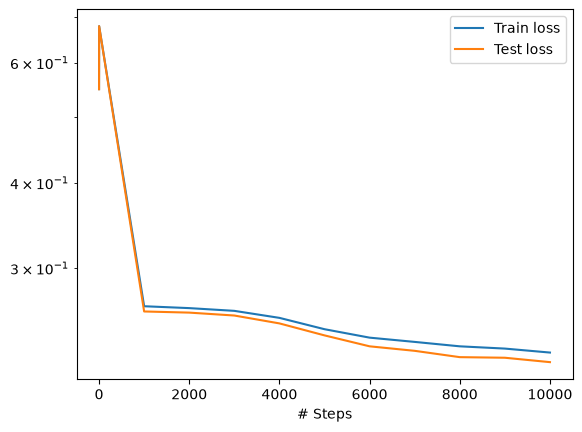

In [41]:
losshistory, train_state = model.train(iterations=15000, callbacks=[variable, early_stop], display_every=1000, disregard_previous_best=True)
dir_name = "stream_function_no_p"
os.makedirs(dir_name, exist_ok=True)
dde.saveplot(losshistory, train_state, issave=True, isplot=True, output_dir=dir_name)

In [42]:
#model checkpoall the plots are saved in ints
ckpt_callback = dde.callbacks.ModelCheckpoint('model_ckpts_1', save_better_only=True)

early_stop2 = dde.callbacks.EarlyStopping(patience=5)

In [43]:
dde.optimizers.config.set_LBFGS_options(maxiter=30000)
model.compile("L-BFGS", lr=1e-4, external_trainable_variables=[dyn_visc])
losshistory, train_state = model.train(callbacks=[variable, ckpt_callback, early_stop2], display_every=1000, disregard_previous_best=True
                                       , batch_size=5000) #length of obs_xyt(full batch)

dir_name = "02_finetuned"
os.makedirs(dir_name, exist_ok=True)
dde.saveplot(losshistory, train_state, issave=True, isplot=True, output_dir=dir_name)

Compiling model...
'compile' took 0.011429 s

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
10005     [3.61e-03, 1.43e-02, 1.68e-01, 4.92e-03, 3.17e-04, 6.52e-03, 1.29e-05]    [4.23e-03, 6.49e-03, 1.68e-01, 4.92e-03, 3.17e-04, 6.52e-03, 1.29e-05]    []  


KeyboardInterrupt: 

In [ ]:
residuals = model.predict(obs_xyt, operator=Navier_stokes)
mean_residuals = np.mean(np.abs(residuals))
print(f"Mean Residual: {mean_residuals:.4e}")

Mean Residual: 2.7356e-04


In [ ]:
output_dir = "models_2"
os.makedirs(output_dir, exist_ok=True)
model.save(os.path.join(output_dir, "stream_function_no_p"), protocol="backend", verbose=0)

'models_2/no_observe_p_exp-11429.weights.h5'

EVALUATION

In [ ]:
#On the anchor points

predictions = model.predict(obs_xyt)
u_preds = predictions[:, 0:1]
v_preds = predictions[:, 1:2]
p_preds = predictions[:, 2:3]

error_u = dde.metrics.l2_relative_error(obs_u, u_preds)
error_v = dde.metrics.l2_relative_error(obs_v, v_preds)
error_p = dde.metrics.l2_relative_error(obs_p, p_preds)

print(f"u error: {error_u:.4e}, v error: {error_v:.4e}, p error: {error_p:.4e}")

u error: 1.3924e-02, v error: 1.0028e+00, p error: 1.0077e+00


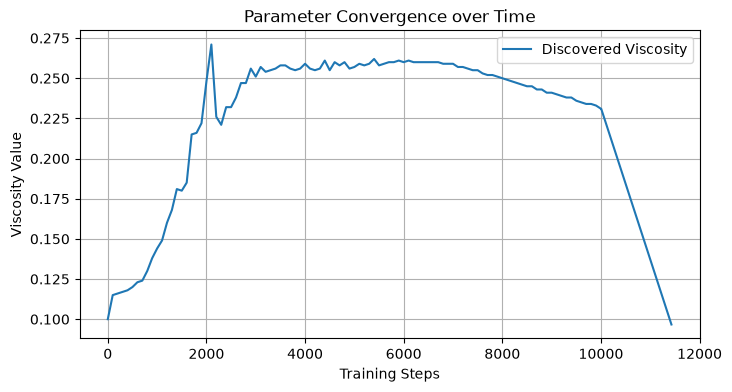

In [ ]:
#Checking if the variable value converged well or if its oscillating/diverging
import io

# 1. Read the raw file and strip out the brackets
with open('stream_function_no_p.dat', 'r') as f:
    clean_text = f.read().replace('[', '').replace(']', '')

# 2. Load the cleaned text using io.StringIO
var_data = np.loadtxt(io.StringIO(clean_text))

steps = var_data[:, 0]
visc_history = var_data[:, 1]

plt.figure(figsize=(8, 4))
plt.plot(steps, visc_history, label="Discovered Viscosity")
plt.xlabel("Training Steps")
plt.ylabel("Viscosity Value")
plt.title("Parameter Convergence over Time")
plt.grid(True)
plt.legend()
plt.show()

Loading a model and checking the heatmaps

In [15]:
layer_sizes = [3, 100, 100, 100, 100, 3]
activation_func = "tanh"

keras_model = tf.keras.Sequential()

keras_model.add(tf.keras.layers.Input(shape=(layer_sizes[0],)))

# Hidden Layers
for hidden_units in layer_sizes[1:-1]:
    keras_model.add(tf.keras.layers.Dense(units=hidden_units, activation=activation_func))

# Output Layer (PINNs typically use linear/no activation for predictions)
keras_model.add(tf.keras.layers.Dense(units=layer_sizes[-1], activation=None))

# 2. Populate the weights directly from your H5 file
# (This bypasses any need for compilation, loss, or optimizer matching)
keras_model.load_weights("models_2/model_7-exponential_decay.weights.h5") 

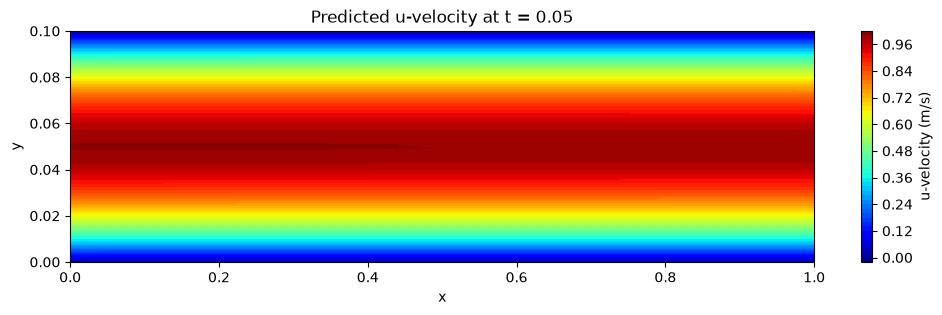

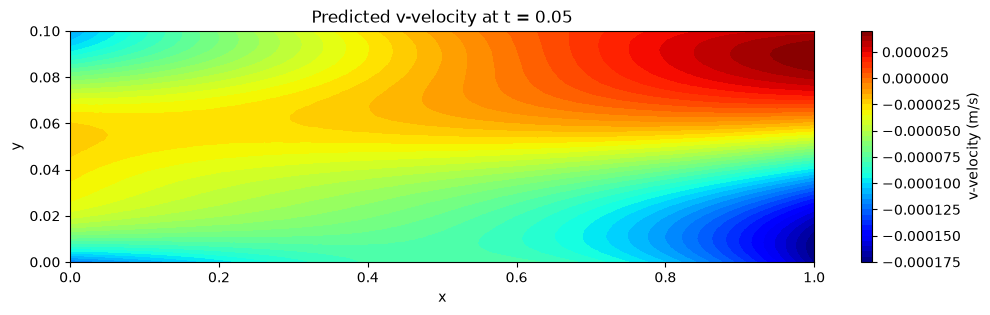

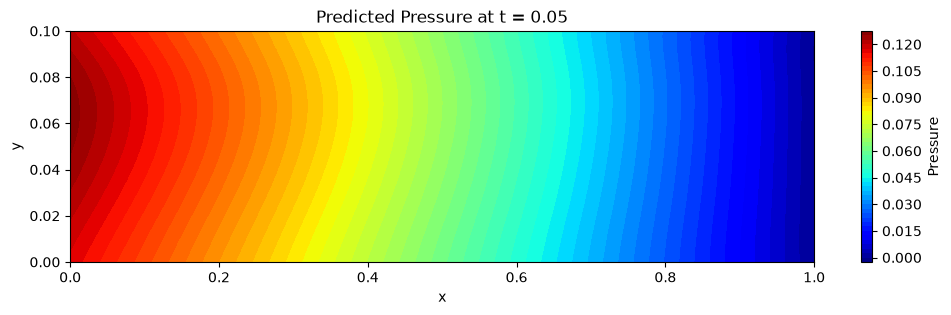

In [ ]:
#Plotting the fluid flow
x_grid = np.linspace(0.0, 1.0, 200)
y_grid = np.linspace(0.0, 0.1, 50)

X, Y = np.meshgrid(x_grid, y_grid)

T = np.full_like(X, 0.05)


grid_xyt = np.vstack((X.flatten(), Y.flatten(), T.flatten())).T
pred_grid = model.predict(grid_xyt)

U_pred = pred_grid[:, 0].reshape(X.shape)
V_pred = pred_grid[:, 1].reshape(X.shape)
P_pred = pred_grid[:, 2].reshape(X.shape)

# 4. Plot U-Velocity Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, U_pred, levels=50, cmap='jet')
plt.colorbar(label='u-velocity (m/s)')
plt.title('Predicted u-velocity at t = 0.05')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# 5. Plot V-Velocity Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, V_pred, levels=50, cmap='jet')
plt.colorbar(label='v-velocity (m/s)')
plt.title('Predicted v-velocity at t = 0.05')
plt.xlabel('x')
plt.ylabel('y')
plt.show() 

# 6. Plot Pressure Heatmap
plt.figure(figsize=(12, 3))
plt.contourf(X, Y, P_pred, levels=50, cmap='jet')
plt.colorbar(label='Pressure')
plt.title('Predicted Pressure at t = 0.05')
plt.xlabel('x')
plt.ylabel('y')
plt.show()



In [ ]:
#Checking on random points(residual error)
# Generate random points in the domain
test_x = np.random.uniform(0.0, 1.0, (5000, 1))
test_y = np.random.uniform(0.0, 0.1, (5000, 1))
test_t = np.random.uniform(0.0, 0.1, (5000, 1))
test_xyt = np.hstack((test_x, test_y, test_t))

# Evaluate the PDE operator
residuals = model.predict(test_xyt, operator=Navier_stokes)

res_cont = np.abs(residuals[0])
res_x_mom = np.abs(residuals[1])
res_y_mom = np.abs(residuals[2])

print(f"Mean Continuity Residual: {np.mean(res_cont):.4e}")
print(f"Mean X-Momentum Residual: {np.mean(res_x_mom):.4e}")
print(f"Mean Y-Momentum Residual: {np.mean(res_y_mom):.4e}")


Mean Continuity Residual: 2.4555e-04
Mean X-Momentum Residual: 3.7801e-04
Mean Y-Momentum Residual: 1.0751e-04


In [ ]:
#checking outputs on random points

test_pts = np.array([
    [0.05, 0.05, 0.05], [0.15, 0.05, 0.05], [0.20, 0.05, 0.05], [0.25, 0.05, 0.05], [0.30, 0.05, 0.05], [0.35, 0.05, 0.05], [0.45, 0.05, 0.05],
    [0.55, 0.05, 0.05], [0.65, 0.05, 0.05], [0.75, 0.05, 0.05], [0.85, 0.05, 0.05], [0.95, 0.05, 0.05]
])

# Evaluate the PDE operator
outputs = model.predict(test_pts)
sum_u_vel = 0
sum_v_vel = 0
sum_p = 0
for output in outputs:
    print(f"u vel: {output[0]}, v vel: {output[1]}, pressure: {output[2]}")
    sum_u_vel += output[0]
    sum_v_vel += output[1]
    sum_p += output[2]



mean_u_vel_centre = sum_u_vel / len(test_pts)
mean_v_vel_centre = sum_v_vel / len(test_pts)
mean_p_centre = sum_p / len(test_pts)
print(mean_u_vel_centre, mean_v_vel_centre, mean_p_centre)

u vel: 1.0005967617034912, v vel: -2.6205088943243027e-05, pressure: 0.11997862160205841
u vel: 1.0006017684936523, v vel: -2.9781367629766464e-05, pressure: 0.10875846445560455
u vel: 1.0005943775177002, v vel: -3.077974542975426e-05, pressure: 0.10299980640411377
u vel: 1.000579833984375, v vel: -3.139069303870201e-05, pressure: 0.09714546799659729
u vel: 1.0005571842193604, v vel: -3.180047497153282e-05, pressure: 0.09119796752929688
u vel: 1.0005254745483398, v vel: -3.193831071257591e-05, pressure: 0.08515993505716324
u vel: 1.000431776046753, v vel: -3.2076146453619e-05, pressure: 0.07282480597496033
u vel: 1.0002939701080322, v vel: -3.2407697290182114e-05, pressure: 0.06016532704234123
u vel: 1.0001047849655151, v vel: -3.391271457076073e-05, pressure: 0.04720976576209068
u vel: 0.9998583793640137, v vel: -3.713509067893028e-05, pressure: 0.0339873842895031
u vel: 0.9995489120483398, v vel: -4.267273470759392e-05, pressure: 0.020529504865407944
u vel: 0.999168872833252, v vel: 

Contriction analysis

In [ ]:
#generating the pressure grid
test_x = np.random.uniform(0.0, 1.0, (5000, 1))
test_y = np.random.uniform(0.0, 0.1, (5000, 1))
test_t = np.random.uniform(0.0, 0.1, (5000, 1))
test_xyt = np.hstack((test_x, test_y, test_t))

dp_dx = model.predict(test_xyt, operator=lambda x, y : dde.grad.jacobian(y, x, i=2, j=0))
p = model.predict(test_xyt)[:, 2:3]

print(max(p), min(p), np.mean(p))

print(len(dp_dx))
print(min(dp_dx), max(dp_dx), np.mean(dp_dx))


[0.12619919] [-1.5608035e-05] 0.06316009
5000
[-0.14134774] [-0.09933363] -0.123106286


In [ ]:
# quantifying BC satisfaction directly rather than reading the colormap
wall_bottom = np.hstack([np.linspace(0,1,200)[:,None], np.zeros((200,1)), np.full((200,1),0.05)])
wall_top    = np.hstack([np.linspace(0,1,200)[:,None], np.full((200,1),0.1), np.full((200,1),0.05)])

v_bottom = model.predict(wall_bottom)[:,1]
v_top = model.predict(wall_top)[:,1]

print("max |v| at bottom wall:", np.max(np.abs(v_bottom)))
print("max |v| at top wall:", np.max(np.abs(v_top)))

max |v| at bottom wall: 0.00017091027
max |v| at top wall: 0.00011050096


In [ ]:
x_sweep = np.linspace(0.85, 1.0, 100)
y_mid = np.full_like(x_sweep, 0.05)
t_fixed = np.full_like(x_sweep, 0.05)
X_check = np.stack([x_sweep, y_mid, t_fixed], axis=1)

dp_dx_check = model.predict(X_check, operator=lambda x, y: dde.grad.jacobian(y, x, i=2, j=0))
print(dp_dx_check.flatten())

[-0.13564685 -0.13567758 -0.1357082  -0.1357388  -0.13576937 -0.13579977
 -0.13583013 -0.13586034 -0.13589054 -0.13592067 -0.13595068 -0.13598076
 -0.13601057 -0.13604034 -0.13607013 -0.13609971 -0.13612941 -0.13615888
 -0.13618837 -0.13621767 -0.13624695 -0.13627613 -0.13630527 -0.13633431
 -0.13636337 -0.13639225 -0.1364211  -0.13644981 -0.13647857 -0.13650711
 -0.13653557 -0.136564   -0.13659245 -0.13662072 -0.13664895 -0.13667703
 -0.13670516 -0.13673313 -0.1367611  -0.13678886 -0.13681662 -0.13684428
 -0.13687196 -0.13689941 -0.13692683 -0.13695431 -0.13698155 -0.13700882
 -0.13703606 -0.13706303 -0.13709    -0.13711692 -0.13714385 -0.13717055
 -0.13719721 -0.13722381 -0.13725036 -0.13727686 -0.13730319 -0.13732953
 -0.13735573 -0.13738191 -0.13740803 -0.13743396 -0.13745993 -0.13748576
 -0.13751146 -0.13753714 -0.13756283 -0.13758829 -0.1376138  -0.13763916
 -0.13766453 -0.1376896  -0.13771491 -0.13773994 -0.13776493 -0.13778983
 -0.13781476 -0.1378395  -0.13786416 -0.13788879 -0